## 0. Imports/Constants

In [655]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.nu import NU
from sbnd.cafclasses.pfp import PFP
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [656]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

BASE_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PLOT_DIR = f'{BASE_DIR}/plots/{day}'

In [657]:
MC_FNAME = f'{BASE_DIR}/mc_syst/v4/mc_smallpand_nosyst_nocuts_recomb.df'
MC_LOWE_FNAME = f'{BASE_DIR}/mc_lowe/v4/mc_smallpand_nosyst_nocuts_recomb.df'
OFFBEAM_FNAME = f'{BASE_DIR}/offbeam/v4/mc_smallpand_nosyst_nocuts_recomb.df'
DATA_FNAME = f'{BASE_DIR}/data/v4/dataonbeam_nocuts.df'

## 1. Load data

In [658]:
# Get keys for h5 files
import h5py
mcnu_keys = []
mcnu_lowe_keys = []

#Slices
mc_pand_keys = []
mc_lowe_pand_keys = []
offbeam_pand_keys = []
data_pand_keys = []
#Tracks
mc_trk_keys = []
mc_lowe_trk_keys = []
offbeam_trk_keys = []
data_trk_keys = []


#Headers
hdr_keys = []
mc_lowe_hdr_keys = []
offbeam_hdr_keys = []
data_hdr_keys = []

#POT and total event keys
mc_pot_keys = []
mc_lowe_pot_keys = []
offbeam_pot_keys = []
data_pot_keys = []

mc_genevt_keys = []
mc_lowe_genevt_keys = []
offbeam_genevt_keys = []
data_genevt_keys = []
# Check the keys in the H5 Files
for fname in [MC_FNAME,OFFBEAM_FNAME,DATA_FNAME,MC_LOWE_FNAME]:
  print(f'File: {fname}')
  with h5py.File(f'{fname}', 'r') as f:
    # Store all keys at the root level
    for key in f.keys():
      if 'pand' in key:
        if fname == MC_FNAME:
          mc_pand_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pand_keys.append(key)
      elif 'trk' in key:
        if fname == MC_FNAME:
          mc_trk_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_trk_keys.append(key)
        elif fname == DATA_FNAME:
          data_trk_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_trk_keys.append(key)
      elif 'mcnu' in key:
        if fname == MC_FNAME:
          mcnu_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mcnu_lowe_keys.append(key)
      elif 'hdr' in key:
        if fname == MC_FNAME:
          hdr_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_hdr_keys.append(key)
      elif 'histpotdf' in key:
        if fname == MC_FNAME:
          mc_pot_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pot_keys.append(key)
        elif fname == DATA_FNAME:
          data_pot_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pot_keys.append(key)
      elif 'histgenevtdf' in key:
        if fname == MC_FNAME:
          mc_genevt_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_genevt_keys.append(key)
        elif fname == DATA_FNAME:
          data_genevt_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_genevt_keys.append(key)
#print(mc_pand_keys,offbeam_pand_keys,mcnu_keys,mcnu_lowe_keys,hdr_keys,offbeam_hdr_keys,data_hdr_keys,mc_trk_keys,offbeam_trk_keys,data_trk_keys,mc_lowe_trk_keys)

File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v4/mc_smallpand_nosyst_nocuts_recomb.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v4/mc_smallpand_nosyst_nocuts_recomb.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/v4/dataonbeam_nocuts.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_lowe/v4/mc_smallpand_nosyst_nocuts_recomb.df


In [659]:
offbeam_genevt_keys

['histgenevtdf_0']

In [ ]:
#Get POT from the h5
POT_MC = 0
for key in mc_pot_keys:
  potdf_mc = pd.read_hdf(MC_FNAME,key=key)
  POT_MC += potdf_mc.TotalPOT.values.sum()
print(f'POT_MC: {POT_MC:.2e}')

POT_MC_LOWE = 0
for key in mc_lowe_pot_keys:
  potdf_mc_lowe = pd.read_hdf(MC_LOWE_FNAME,key=key)
  POT_MC_LOWE += potdf_mc_lowe.TotalPOT.values.sum()
# for key in mc_lowe_hdr_keys:
#   potdf_mc_lowe = pd.read_hdf(MC_LOWE_FNAME,key=key)
#   POT_MC_LOWE += potdf_mc_lowe.pot.values.sum()
print(f'POT_MC_LOWE: {POT_MC_LOWE:.2e}')

LIVETIME_OFFBEAM = 0
for key in offbeam_genevt_keys:
  genevt_offbeam = pd.read_hdf(OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM += genevt_offbeam.TotalGenEvents.values.sum()
# for key in offbeam_hdr_keys:
#   hdr_offbeam = pd.read_hdf(OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM += hdr_offbeam.ngenevt.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')

LIVETIME_DATA = 0
POT_DATA = 0
for key in data_hdr_keys:
  hdr_data = pd.read_hdf(DATA_FNAME,key=key)
  LIVETIME_DATA += hdr_data.noffbeambnb.values.sum()
  POT_DATA += hdr_data.pot.values.sum()
LIVETIME_DATA = 9.51e5 # Temporary
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_DATA: {POT_DATA:.2e}')

#print('WARNING: Setting LIVETIME_OFFBEAM to LIVETIME_DATA for now')
#LIVETIME_OFFBEAM = LIVETIME_DATA

POT_MC: 1.45e+18
POT_MC_LOWE: 5.89e+17
Index(['TotalGenEvents'], dtype='object')
LIVETIME_OFFBEAM: 9.85e+04
LIVETIME_DATA: 9.51e+05
POT_DATA: 4.92e+18


In [567]:
mc_lowe_pand_keys

['evt_pand_0']

In [568]:
#TODO: Add option to load multiple keys
slc_mc = CAFSlice.load(MC_FNAME,key=mc_pand_keys[0],pot=POT_MC)
slc_offbeam = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys[0],livetime=LIVETIME_OFFBEAM)
slc_data = CAFSlice.load(DATA_FNAME,key=data_pand_keys[0],livetime=LIVETIME_DATA,pot=POT_DATA)
slc_mc_lowe = CAFSlice.load(MC_LOWE_FNAME,key=mc_lowe_pand_keys[0],pot=POT_MC_LOWE)

mcnu = NU.load(MC_FNAME,key=mcnu_keys[0])
mcnu_lowe = NU.load(MC_LOWE_FNAME,key=mcnu_lowe_keys[0])

trk_mc = PFP.load(MC_FNAME,key=mc_trk_keys[0])
trk_mc_lowe = PFP.load(MC_LOWE_FNAME,key=mc_lowe_trk_keys[0])
trk_offbeam = PFP.load(OFFBEAM_FNAME,key=offbeam_trk_keys[0])
trk_data = PFP.load(DATA_FNAME,key=data_trk_keys[0])


### 1.1 Scale samples

In [569]:
slc_mc.scale_to_pot(POT_DATA,sample_pot=POT_MC)
slc_mc_lowe.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)

trk_mc.scale_to_pot(POT_DATA,sample_pot=POT_MC)
trk_mc_lowe.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
trk_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)

POT_LABEL = f'{POT_DATA:.2e} POT'
LIVETIME_LABEL = f'{LIVETIME_DATA:.2e} livetime'
POT_LABEL

--scaling to POT (3.40e+00): 1.45e+18 -> 4.92e+18
--scaling to POT (8.36e+00): 5.89e+17 -> 4.92e+18
--scaling to livetime (1.01e+00): 9.44e+05 --> 9.51e+05
--scaling to POT (3.40e+00): 1.45e+18 -> 4.92e+18
--scaling to POT (8.36e+00): 5.89e+17 -> 4.92e+18
--scaling to livetime (1.01e+00): 9.44e+05 --> 9.51e+05


'4.92e+18 POT'

### 1.2 Combine the offbeam to the MC sample

In [570]:
slc_mc.combine(slc_offbeam,duplicate_ok=True)
del slc_offbeam
slc_mc.combine(slc_mc_lowe,duplicate_ok=True,offset=int(2e5))
del slc_mc_lowe

trk_mc.combine(trk_offbeam,duplicate_ok=True)
del trk_offbeam
trk_mc.combine(trk_mc_lowe,duplicate_ok=True,offset=int(2e5))
del trk_mc_lowe

In [571]:
mcnu.combine(mcnu_lowe,duplicate_ok=True)
del mcnu_lowe

## 2. BCFM plots

### 2.1 Break into lists of objects

In [572]:
slcs = []

#Get event type col
slc_event_type_col = slc_mc.get_key('truth.event_type')

# Group data by event type once
slc_groups = slc_mc.data.groupby(slc_event_type_col)

#Create objects only for groups that exist
for key,val in EVENT_TYPE_LIST.items():
  if key in slc_groups.groups:
    slcs.append(CAFSlice(slc_groups.get_group(key)))

/tmp/ipykernel_7573/3773502384.py:12: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  slcs.append(CAFSlice(slc_groups.get_group(key)))


In [630]:
#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
  if key == -1:# or key == 4: #Skip nuecc since it's not in small sample
    continue
  labels.append(item[0])
  names.append(item[1])
  colors.append(item[2])

slc_weights = [s.data.genweight for s in slcs]
assert [any(np.isnan(sw)) or any(np.isinf(sw)) for sw in slc_weights].count(True) == 0


In [631]:
labels

['$\\nu_\\mu$ CC (cont.)',
 '$\\nu_\\mu$ CC (exit.)',
 '$\\nu_\\mu$ CC (OOPS)',
 'Non-AV',
 '$\\nu_e$ CC',
 '$\\nu$ NC',
 'Cosmic']

### 2.2 Make the plots

In [632]:
from sbnd.plotlibrary import makeplot
from sbnd.general import plotters
from naming import PANDORA_QUALIFIER_INTERNAL_LABEL

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()


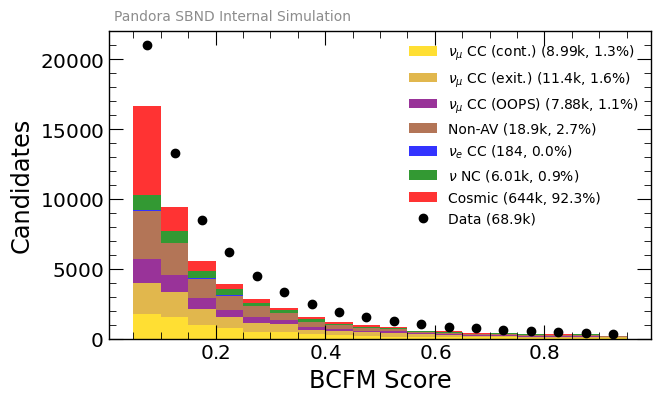

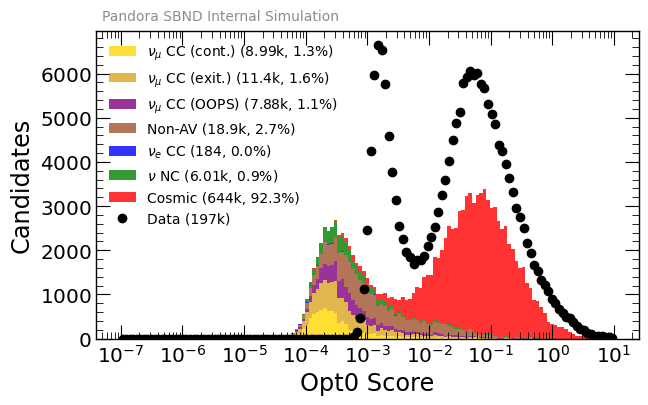

In [640]:
bcfm_score = [s.data.slc.barycenterFM.score for s in slcs]
opt0_score = [1/s.data.slc.opt0.score for s in slcs]

bcfm_score_data = slc_data.data.slc.barycenterFM.score
opt0_score_data = 1/slc_data.data.slc.opt0.score

bcfm_bins = np.arange(0.05,1.,0.05)
opt0_bins = np.logspace(-7,1,140)

fig,ax = makeplot.create_hist(
    bcfm_score, 
    labels,
    dens=False,
    bins=bcfm_bins,
    data_series=bcfm_score_data,
    weights=slc_weights,
    cut_desc='',
    xlabel='BCFM Score',
    colors=colors,
    label=PANDORA_QUALIFIER_INTERNAL_LABEL,
)

fig,ax = makeplot.create_hist(
    opt0_score, 
    labels,
    dens=False,
    bins=opt0_bins,
    data_series=opt0_score_data,
    weights=slc_weights,
    cut_desc='',
    xlabel='Opt0 Score',
    colors=colors,
    savename='',
    label=PANDORA_QUALIFIER_INTERNAL_LABEL,
)
ax.set_xscale('log')
fig.show()

In [ ]:
#Ok, let's plot pur and eff as function of bcfm score
bcfm_scores = np.linspace(0,0.2,41)
#bcfm_scores = [0.0,1.]
_slc_mc = slc_mc.copy()
#_slc_mc_base.cut_flashmatch(method='barycenterFM',use_isclearcosmic=False,cut=False)

bcfm_purs = []
bcfm_effs = []
bcfm_f1s = []

for score in tqdm(bcfm_scores,unit=' goomba'):
  _slc_mc.cut_cosmic(fmatch_score=score,use_opt0='barycenterFM',nu_score=0.0,use_isclearcosmic=True,cut=False)
  #print(np.sum(_slc_mc.data.cut.cosmic))
  pur,eff,f1,_,_,_ = _slc_mc.get_pur_eff_f1(mcnu,['flashmatch','cosmic'],categories=[0,1])
  bcfm_purs.append(pur)
  bcfm_effs.append(eff)
  bcfm_f1s.append(f1)

41 goomba [05:57,  8.71s/ goomba]


In [579]:
#opt0_scores = np.logspace(-3,-2,20)
opt0_scores = np.logspace(-4,-1,41)
opt0_purs = []
opt0_effs = []
opt0_f1s = []
_slc_mc = slc_mc.copy()
_slc_mc.cut_flashmatch(method='opt0',cut=False,use_isclearcosmic=False)

for score in tqdm(opt0_scores,unit=' goomba'):
  #_slc_mc = _slc_mc.copy()
  #_slc_mc.data.cut.cosmic = False
  #print(np.sum(_slc_mc.data.cut.cosmic))
  _slc_mc.cut_cosmic(fmatch_score=1/score,use_opt0=True,nu_score=0.0,use_isclearcosmic=False,cut=False)
  #print(np.sum(_slc_mc.data.cut.cosmic))
  pur,eff,f1,_,_,_ = _slc_mc.get_pur_eff_f1(mcnu,['flashmatch','cosmic'],categories=[0,1])
  opt0_purs.append(pur)
  opt0_effs.append(eff)
  opt0_f1s.append(f1)

100%|██████████| 41/41 [04:46<00:00,  7.00s/ goomba]


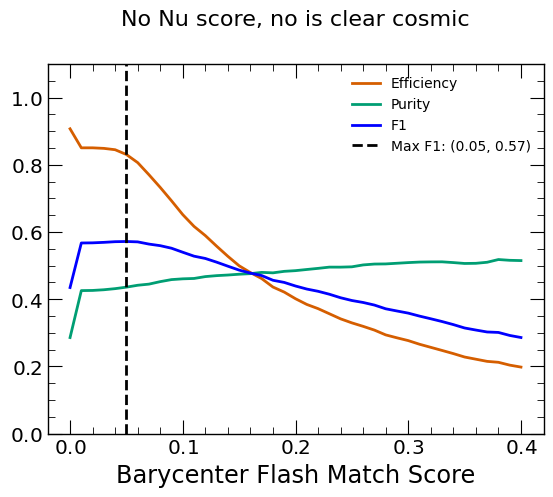

In [642]:
fig,ax = plt.subplots()

ax.plot(bcfm_scores,[p[-1] for p in bcfm_effs],label='Efficiency')
ax.plot(bcfm_scores,[p[-1] for p in bcfm_purs],label='Purity')
ax.plot(bcfm_scores,[p[-1] for p in bcfm_f1s],label='F1',color='blue')

ax.axvline(bcfm_scores[np.argmax([p[-1] for p in bcfm_f1s])],ls='--',color='k',
  label=f'Max F1: ({bcfm_scores[np.argmax([p[-1] for p in bcfm_f1s])]:.2f}, {max([p[-1] for p in bcfm_f1s]):.2f})')
#ax.axhline(np.max([p[-1] for p in bcfm_f1s]),ls='--',color='k')

ax.legend()
ax.set_xlabel('Barycenter Flash Match Score')
ax.set_ylim(0,1.1)
ax.set_title('No Nu score, no is clear cosmic',fontsize=16)
plotters.save_plot('bcfm_pureff.png',fig=fig,folder_name=f'{PLOT_DIR}/fmatch')

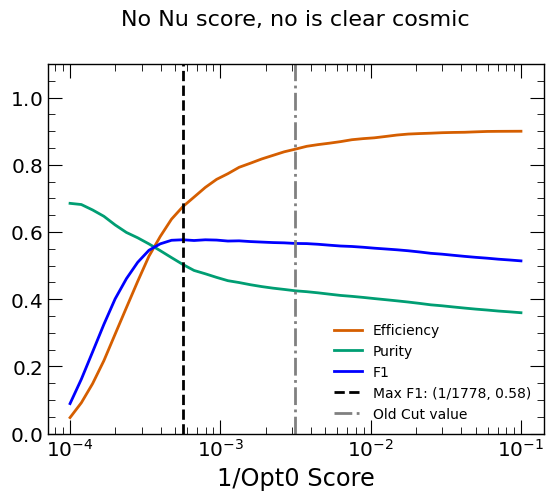

In [643]:
fig,ax2 = plt.subplots()

ax2.plot(opt0_scores,[p[-1] for p in opt0_effs],label='Efficiency')
ax2.plot(opt0_scores,[p[-1] for p in opt0_purs],label='Purity')
ax2.plot(opt0_scores,[p[-1] for p in opt0_f1s],label='F1',color='blue')
ax2.axvline(opt0_scores[np.argmax([p[-1] for p in opt0_f1s])],ls='--',color='k',
  label=f'Max F1: (1/{1/opt0_scores[np.argmax([p[-1] for p in opt0_f1s])]:.0f}, {max([p[-1] for p in opt0_f1s]):.2f})')
ax2.axvline(1/320,ls='-.',color='gray',label='Old Cut value')

ax2.legend()
ax2.set_xscale('log')
ax2.set_xlabel('1/Opt0 Score')
ax2.set_ylim(0,1.1)
ax2.set_title('No Nu score, no is clear cosmic',fontsize=16)
plotters.save_plot('opt0_pureff.png',fig=fig,folder_name=f'{PLOT_DIR}/fmatch')

## 3. Track plots

### 3.0 Apply cuts to reduce to neutrino candidates

In [616]:
#Get slc cut
slc_mc_nocosmic = slc_mc.copy()
slc_mc_nocosmic.cut_cosmic(fmatch_score=0.58,use_opt0='barycenterFM',nu_score=0.5,use_isclearcosmic=False,cut=True)
slc_mc_nocosmic.cut_flashmatch(method='barycenterFM',use_isclearcosmic=False,cut=True)

slc_data_nocosmic = slc_data.copy()
slc_data_nocosmic.cut_cosmic(fmatch_score=0.58,use_opt0='barycenterFM',nu_score=0.5,use_isclearcosmic=False,cut=True)
slc_data_nocosmic.cut_flashmatch(method='barycenterFM',use_isclearcosmic=False,cut=True)

#Get tracks 
trk_mc_nocosmic = trk_mc.copy()
trk_mc_nocosmic.data = slc_mc_nocosmic.get_reference_df(trk_mc_nocosmic)
m = trk_mc_nocosmic.data.pfp.trk.len > 32 # 10 cm
trk_mc_nocosmic.data = trk_mc_nocosmic.data[m]

trk_data_nocosmic = trk_data.copy()
trk_data_nocosmic.data = slc_data_nocosmic.get_reference_df(trk_data_nocosmic)
m = trk_data_nocosmic.data.pfp.trk.len > 32 # 10 cm
trk_data_nocosmic.data = trk_data_nocosmic.data[m]

Applied cut on key: cut.cosmic (186,730 --> 8,914)
Applied cut on key: cut.flashmatch (8,914 --> 8,679)
Applied cut on key: cut.cosmic (903,298 --> 28,105)
Applied cut on key: cut.flashmatch (28,105 --> 27,610)


### 3.1 Break into lists of objects

In [617]:
trks = []

#Get event type col
trk_mc_nocosmic.add_cols('pfp.trk.truth.p.abspdg',np.abs(trk_mc_nocosmic.data.pfp.trk.truth.p.pdg.values),fill=np.int32(0))
trk_true_particle = trk_mc_nocosmic.get_key('pfp.trk.truth.p.abspdg')

# Group data by event type once
trk_groups = trk_mc_nocosmic.data.groupby(trk_true_particle)
missing_keys = []

#Create objects only for groups that exist
for key,val in PARTICLE_TYPE_LIST.items():
  if key in trk_groups.groups:
    trks.append(PFP(trk_groups.get_group(key)))
  else:
    missing_keys.append(key)

/tmp/ipykernel_7573/399178477.py:14: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  trks.append(PFP(trk_groups.get_group(key)))


In [618]:
from sbnd.constants import *

In [624]:
#Get label info
labels = []
names = []
colors = []

for key,item in PARTICLE_TYPE_LIST.items():
  if key in missing_keys:
    continue
  labels.append(item[0])
  names.append(item[1])
  colors.append(item[2])

trk_weights = [s.data.genweight for s in trks]
assert [any(np.isnan(tw)) for tw in trk_weights].count(True) == 0

### 3.2 Make the plots

In [625]:
chi2_bins = np.arange(0,150,2)

chi2_muons = [t.data.pfp.trk.chi2pid.I2.chi2_muon for t in trks]
chi2_protons = [t.data.pfp.trk.chi2pid.I2.chi2_proton for t in trks]

chi2_muons_data = trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_muon
chi2_protons_data = trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_proton

fig,ax = makeplot.create_hist(
    chi2_muons,
    labels,
    dens=False,
    bins=np.arange(0,75,0.5),
    data_series=chi2_muons_data,
    weights=trk_weights,
    cut_desc='',
    xlabel=r'$\chi^2$ Muon',
    colors=colors,
    label=PANDORA_QUALIFIER_INTERNAL_LABEL,
    pot_label=POT_LABEL,
    savename='stacked_chi2_muon',
    plot_dir=f'{PLOT_DIR}/chi2',
)
ax.set_title('Cosmic Cuts Applied, L > 32 cm')
fig.show()

fig,ax = makeplot.create_hist(
    chi2_protons,
    labels,
    dens=False,
    bins=np.arange(0,350,2),
    data_series=chi2_protons_data,
    weights=trk_weights,
    cut_desc='',
    xlabel=r'$\chi^2$ Proton',
    colors=colors,
    label=PANDORA_QUALIFIER_INTERNAL_LABEL,
    pot_label=POT_LABEL,
    savename='stacked_chi2_proton',
    plot_dir=f'{PLOT_DIR}/chi2',
)
ax.set_title('Cosmic Cuts Applied, L > 32 cm')
fig.show()

### 3.3 Plot unstacked histograms with variations and data

In [626]:
#Alpha variables - muon
alpha_muon_keys = ['pfp.trk.chi2pid.I2.chi2_muon_alpha_embm1',
              'pfp.trk.chi2pid.I2.chi2_muon_alpha_embp1',
              'pfp.trk.chi2pid.I2.chi2_muon_alpha_emb00',
              ]
alpha_muon_cols = trk_mc_nocosmic.get_key(alpha_muon_keys)
alpha_proton_keys = ['pfp.trk.chi2pid.I2.chi2_proton_alpha_embm1',
              'pfp.trk.chi2pid.I2.chi2_proton_alpha_embp1',
              'pfp.trk.chi2pid.I2.chi2_proton_alpha_emb00',
              ]
alpha_proton_cols = trk_mc_nocosmic.get_key(alpha_proton_keys)

alpha_labels = [r'$\alpha - 1\sigma$',r'$\alpha + 1\sigma$',r'CV']

#Beta variables - muon
beta_muon_keys = ['pfp.trk.chi2pid.I2.chi2_muon_beta_90m1',
             'pfp.trk.chi2pid.I2.chi2_muon_beta_90p1',
             'pfp.trk.chi2pid.I2.chi2_muon_beta_9000',
             ]
beta_muon_cols = trk_mc_nocosmic.get_key(beta_muon_keys)
beta_proton_keys = ['pfp.trk.chi2pid.I2.chi2_proton_beta_90m1',
             'pfp.trk.chi2pid.I2.chi2_proton_beta_90p1',
             'pfp.trk.chi2pid.I2.chi2_proton_beta_9000',
             ]
beta_proton_cols = trk_mc_nocosmic.get_key(beta_proton_keys)
beta_labels = [r'$\beta - 1\sigma$',r'$\beta + 1\sigma$',r'CV']

#Recombination variables
r_muon_keys = ['pfp.trk.chi2pid.I2.chi2_muon_R_embm1',
              'pfp.trk.chi2pid.I2.chi2_muon_R_embp1',
              'pfp.trk.chi2pid.I2.chi2_muon_R_emb00',
              ]
r_muon_cols = trk_mc_nocosmic.get_key(r_muon_keys)
r_proton_keys = ['pfp.trk.chi2pid.I2.chi2_proton_R_embm1',
              'pfp.trk.chi2pid.I2.chi2_proton_R_embp1',
              'pfp.trk.chi2pid.I2.chi2_proton_R_emb00',]
r_proton_cols = trk_mc_nocosmic.get_key(r_proton_keys)
r_labels = [r'$R - 1\sigma$',r'$R + 1\sigma$',r'CV']
colors = ['blue','orange','green']

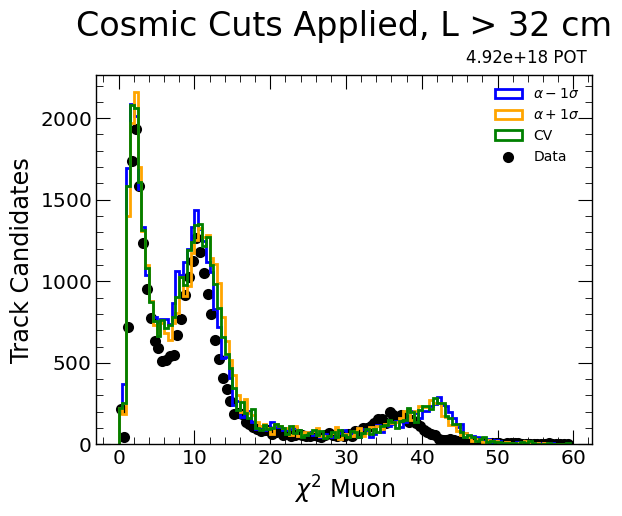

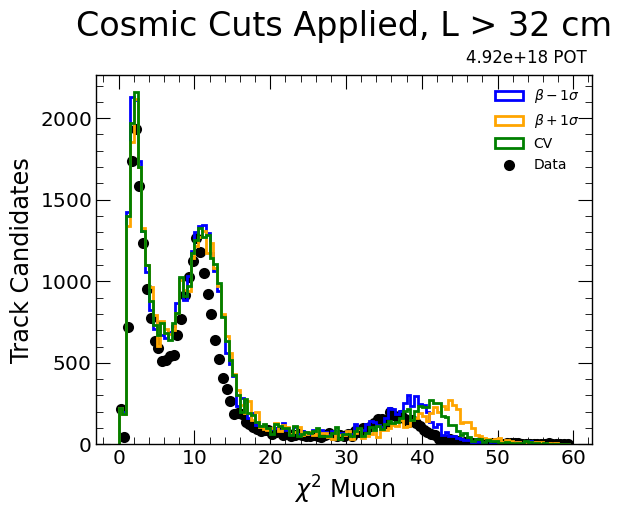

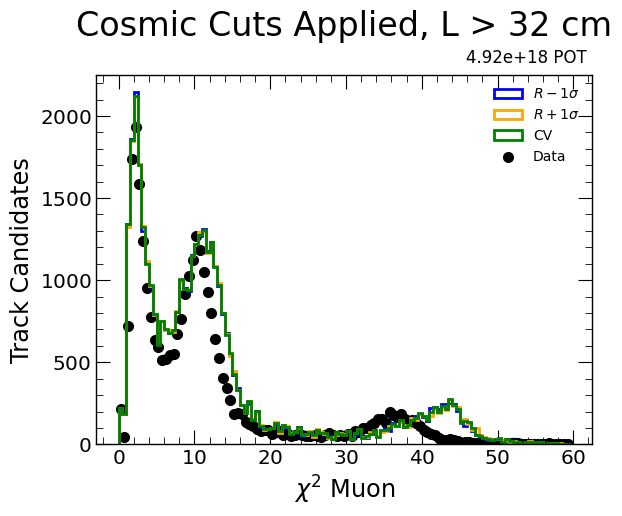

In [627]:
#Muon chi2
chi2_bins = np.arange(0,60,0.5)
fig1,ax1 = plt.subplots()
fig2,ax2 = plt.subplots()
fig3,ax3 = plt.subplots()
for i,(col,label,color) in enumerate(zip(alpha_muon_cols,alpha_labels,colors)):
  ax1.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(beta_muon_cols,beta_labels,colors)):
  ax2.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(r_muon_cols,r_labels,colors)):
  ax3.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
#Data
counts, bin_edges = np.histogram(trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_muon, 
                                  bins=chi2_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
for ax in (ax1,ax2,ax3):
  ax.scatter(bin_centers, counts, color='black', label='Data')
  ax.legend()
  ax.set_xlabel(r'$\chi^2$ Muon')
  ax.set_ylabel('Track Candidates')
  plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
  ax.set_title('Cosmic Cuts Applied, L > 32 cm')

fig1.show()
fig2.show()
fig3.show()
plotters.save_plot('chi2_muon_alpha',fig=fig1,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_muon_beta',fig=fig2,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_muon_R',fig=fig3,folder_name=f'{PLOT_DIR}/chi2')


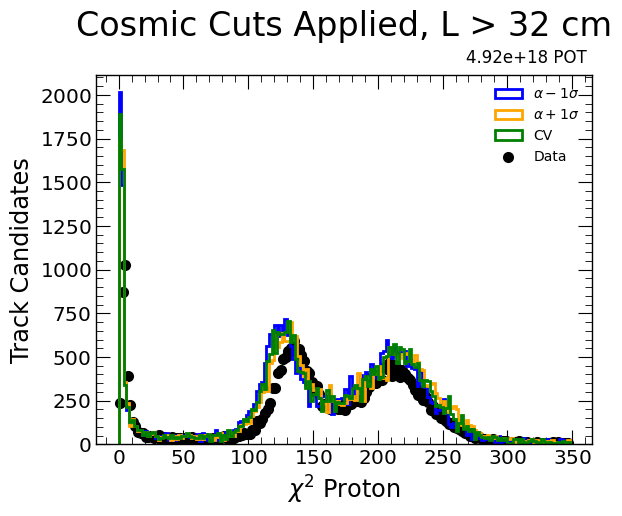

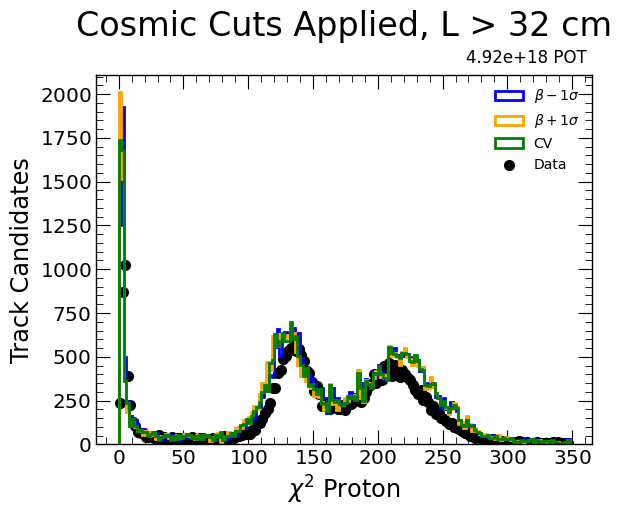

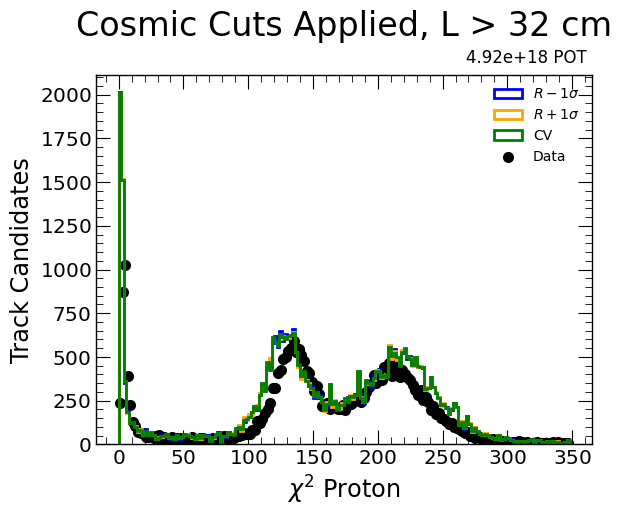

In [628]:
# Proton chi2
chi2_bins = np.arange(0,350,2)
fig1,ax1 = plt.subplots()
fig2,ax2 = plt.subplots()
fig3,ax3 = plt.subplots()
for i,(col,label,color) in enumerate(zip(alpha_proton_cols,alpha_labels,colors)):
  ax1.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(beta_proton_cols,beta_labels,colors)):
  ax2.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
for i,(col,label,color) in enumerate(zip(r_proton_cols,r_labels,colors)):
  ax3.hist(trk_mc_nocosmic.data[col],weights=trk_mc_nocosmic.data.genweight,bins=chi2_bins,color=color,label=label,histtype='step')
#Data
counts, bin_edges = np.histogram(trk_data_nocosmic.data.pfp.trk.chi2pid.I2.chi2_proton, 
                                  bins=chi2_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
for ax in (ax1,ax2,ax3):
  ax.scatter(bin_centers, counts, color='black', label='Data')
  ax.legend()
  ax.set_xlabel(r'$\chi^2$ Proton')
  ax.set_ylabel('Track Candidates')
  plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
  ax.set_title('Cosmic Cuts Applied, L > 32 cm')
fig1.show()
fig2.show()
fig3.show()
plotters.save_plot('chi2_proton_alpha',fig=fig1,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_proton_beta',fig=fig2,folder_name=f'{PLOT_DIR}/chi2')
plotters.save_plot('chi2_proton_R',fig=fig3,folder_name=f'{PLOT_DIR}/chi2')

## Testing

In [413]:
fname = '/exp/sbnd/data/users/apapadop/dfs/v10_14_00/data_MCP2025C_FallValidationII_offbnblight_v10_14_00_flatcaf_sbnd.df'
fname = MC_FNAME
with h5py.File(fname, 'r') as f:
  keys = list(f.keys())
print(keys)

['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split', 'trk_0']


In [415]:
df = pd.read_hdf(fname,key='histpotdf_0')
df.TotalPOT.values.sum()

1378889283925906.8

In [36]:
df.noffbeambnb.values.sum()

1661243.0